In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

In [8]:
pd.read_excel("StudentsPerformance.xlsx")
df= pd.read_excel("StudentsPerformance.xlsx")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
print("Dataset Shape:", df.shape)

print(df.info())

Dataset Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
missing_counts = df.isna().sum()

print(missing_counts)

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


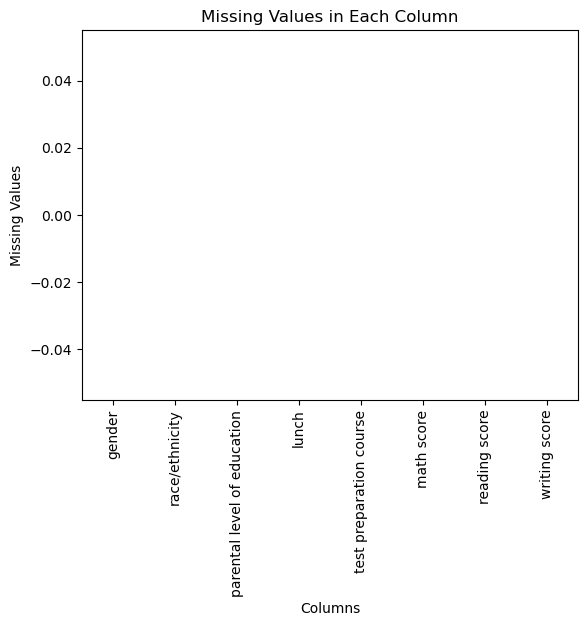

In [18]:
import matplotlib.pyplot as plt

missing_counts.plot(kind='bar')

plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values")

plt.xticks(rotation=90)

plt.show()

In [20]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [21]:
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed")
else:
    print("No duplicates found")

No duplicates found


In [22]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group b,bachelor's degree,standard,none,72,72,74
1,female,group c,some college,standard,completed,69,90,88
2,female,group b,master's degree,standard,none,90,95,93
3,male,group a,associate's degree,free/reduced,none,47,57,44
4,male,group c,some college,standard,none,76,78,75


In [23]:
print(df.dtypes)

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


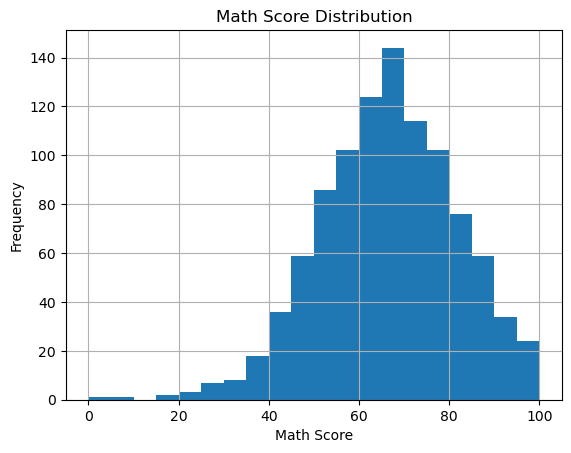

In [24]:
df["math score"].hist(bins=20)

plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.show()

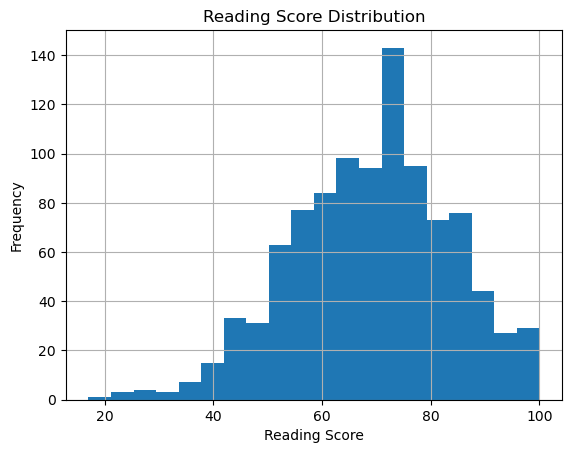

In [25]:
df["reading score"].hist(bins=20)

plt.title("Reading Score Distribution")
plt.xlabel("Reading Score")
plt.ylabel("Frequency")

plt.show()

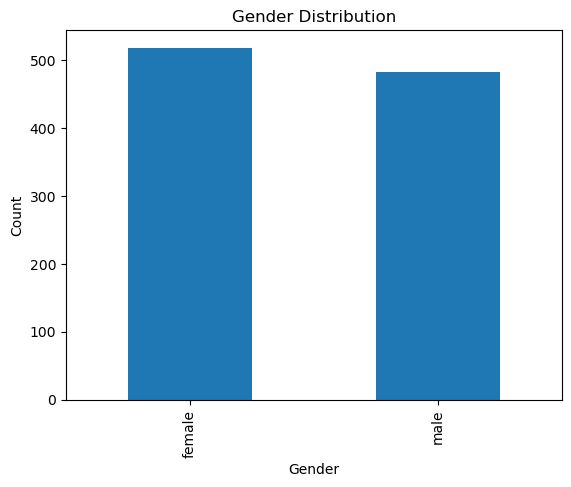

In [26]:
df["gender"].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [27]:
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

In [28]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group b,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group c,some college,standard,completed,69,90,88,82.333333
2,female,group b,master's degree,standard,none,90,95,93,92.666667
3,male,group a,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group c,some college,standard,none,76,78,75,76.333333


In [29]:
target_col = "average_score"

In [30]:
X = df.drop(columns=[target_col])

y = df[target_col]

In [31]:
print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (1000, 8)
Target Shape: (1000,)


In [32]:
df.to_csv("StudentsPerformance_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
